# Climate- and case-blind susceptible-terrain pilot

This notebook executes protocol v0.4 for three RGI-selected validation windows. It loads no failure catalog, event coordinate, or climate reanalysis. The maps show geometrical strata, not predicted failures; the volume cutoff is conditional on prescribed depth.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT))
from scripts.denominator_pilot import WINDOWS, contact_distance, pzi_classes, region_layers, slope_degrees
s=pd.read_csv(ROOT/'data/denominator/summary.csv',dtype={'region':str}); w=pd.read_csv(ROOT/'data/denominator/windows.csv',dtype={'region':str})
plt.rcParams.update({'font.size':9,'axes.titlesize':10,'axes.labelsize':9})

## Registered primary definitions and sensitivities

The primary rock-slope calculation uses 30 m slope, 30°, 100 m glacier contact, and PZI ≥0.1. Counts include boundary-truncated objects here; the committed summary also reports contained objects separately.

In [2]:
primary=s[(s.edge_scope=='all')&(((s.stratum=='glacier')&(s.resolution_m==0))|((s.stratum=='glacier_contact')&(s.resolution_m==30)&(s.slope_deg==30)&(s.contact_m==100))|((s.stratum=='permafrost')&(s.resolution_m==30)&(s.slope_deg==30)&(s.pzi_min==.1)))].copy()
primary['area_km2']=primary.area_m2/1e6
display(primary[['region_name','stratum','object_count','area_km2','eligible_d10_count','eligible_d30_count','eligible_d100_count']])
resolution=s[(s.edge_scope=='all')&(s.slope_deg==30)&(((s.stratum=='glacier_contact')&(s.contact_m==100))|((s.stratum=='permafrost')&(s.pzi_min==.1)))].copy(); resolution['area_km2']=resolution.area_m2/1e6
display(resolution[['region_name','stratum','resolution_m','object_count','area_km2','eligible_d30_count']])

,region_name,stratum,object_count,area_km2,eligible_d10_count,eligible_d30_count,eligible_d100_count
0,Alaska,glacier,140,467.217455,123,137,139
10,Alaska,glacier_contact,1766,50.603400,131,331,617
42,Alaska,permafrost,3672,343.110600,402,724,1228
62,Central Europe,glacier,472,366.916148,237,340,468
72,Central Europe,glacier_contact,2872,108.156600,292,611,1067
104,Central Europe,permafrost,5321,710.943300,411,753,1501
124,Central Asia,glacier,144,105.426195,93,117,143
134,Central Asia,glacier_contact,742,33.275700,105,220,336
166,Central Asia,permafrost,7099,394.899300,556,1086,2156


,region_name,stratum,resolution_m,object_count,area_km2,eligible_d30_count
10,Alaska,glacier_contact,30,1766,50.6034,331
28,Alaska,glacier_contact,90,1022,46.5345,301
42,Alaska,permafrost,30,3672,343.1106,724
54,Alaska,permafrost,90,1892,281.8881,753
72,Central Europe,glacier_contact,30,2872,108.1566,611
90,Central Europe,glacier_contact,90,1838,114.7770,598
104,Central Europe,permafrost,30,5321,710.9433,753
116,Central Europe,permafrost,90,2632,635.7933,1027
134,Central Asia,glacier_contact,30,742,33.2757,220
152,Central Asia,glacier_contact,90,589,34.3926,220


## Selected windows and primary terrain masks

Cyan is RGI glacier area, magenta is steep glacier-contact terrain, and orange is steep PZI ≥0.1 terrain. Overlap is allowed and the strata must not be summed.

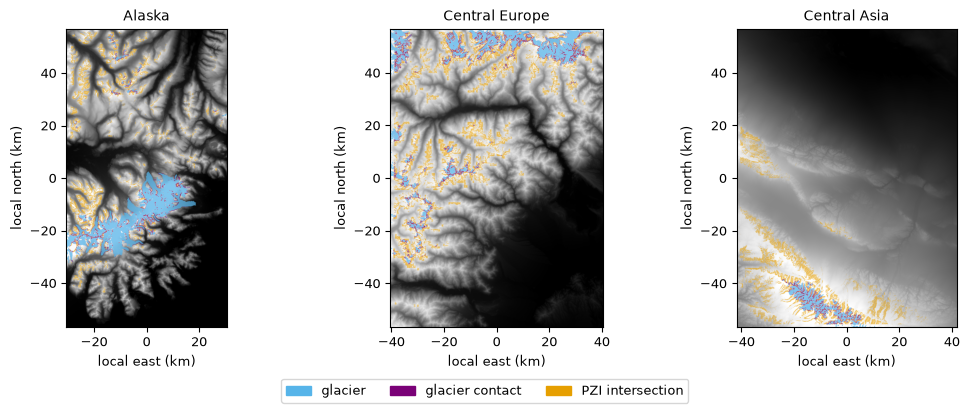

In [3]:
fig,axes=plt.subplots(1,3,figsize=(10.5,4),constrained_layout=True)
for ax,region in zip(axes,WINDOWS):
 z,affine,_,_,_,report,glaciers,pzi=region_layers(region)
 slope=slope_degrees(z,30); pzi_primary=pzi_classes(pzi)[0]
 contact=(slope>=30)&~glaciers&(contact_distance(glaciers,30)<=100)&report
 permafrost=(slope>=30)&~glaciers&pzi_primary&report
 extent=np.array([affine.c,affine.c+affine.a*z.shape[1],affine.f+affine.e*z.shape[0],affine.f])/1000; step=2
 limits=np.nanpercentile(z[report],[3,97]); ax.imshow(z[::step,::step],extent=extent,cmap='Greys_r',vmin=limits[0],vmax=limits[1])
 for mask,color,alpha in ((permafrost,'#e69f00',.65),(glaciers,'#56b4e9',.75),(contact,'#7a0177',1)): ax.imshow(np.ma.masked_where(~mask[::step,::step],mask[::step,::step]),extent=extent,cmap=plt.matplotlib.colors.ListedColormap([color]),alpha=alpha)
 ax.set(title=WINDOWS[region][0],xlabel='local east (km)',ylabel='local north (km)')
fig.legend(handles=[Patch(color=c,label=l) for c,l in [('#56b4e9','glacier'),('#7a0177','glacier contact'),('#e69f00','PZI intersection')]],loc='outside lower center',ncol=3)
fig.savefig(ROOT/'figures/denominator_windows.png',dpi=180,bbox_inches='tight'); fig.savefig(ROOT/'figures/denominator_windows.pdf',bbox_inches='tight')
plt.show()

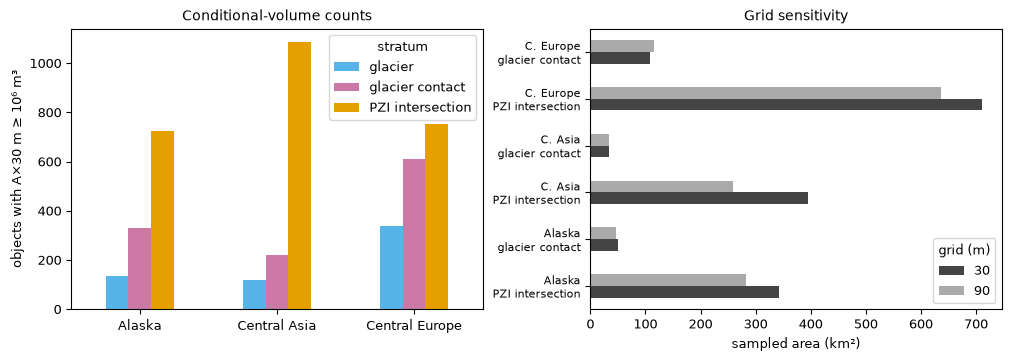

In [4]:
labels={'glacier':'glacier','glacier_contact':'glacier contact','permafrost':'PZI intersection'}
fig,axes=plt.subplots(1,2,figsize=(10,3.5),constrained_layout=True)
counts=primary.pivot(index='region_name',columns='stratum',values='eligible_d30_count').rename(columns=labels); counts.plot.bar(ax=axes[0],color=['#56b4e9','#cc79a7','#e69f00']); axes[0].set(ylabel='objects with A×30 m ≥ 10⁶ m³',xlabel='',title='Conditional-volume counts'); axes[0].tick_params(axis='x',rotation=0); axes[0].legend(title='stratum')
resolution['label']=resolution.region_name.str.replace('Central ','C. ')+"\n"+resolution.stratum.map(labels)
grid=resolution.pivot(index='label',columns='resolution_m',values='area_km2'); grid.plot.barh(ax=axes[1],color=['#444444','#aaaaaa']); axes[1].set(xlabel='sampled area (km²)',ylabel='',title='Grid sensitivity'); axes[1].tick_params(axis='y',labelsize=8); axes[1].legend(title='grid (m)')
fig.savefig(ROOT/'figures/denominator_sensitivity.png',dpi=180,bbox_inches='tight'); fig.savefig(ROOT/'figures/denominator_sensitivity.pdf',bbox_inches='tight')
plt.show()

## Bounded reading

The pilot succeeds as a reproducible terrain enumeration, but not yet as a stable object-count denominator. From 30 to 90 m, primary glacier-contact area changes by −8% to +6%, whereas permafrost-intersection area decreases by 11–35%. Connected-component counts fall by factors of about 1.3–3.0. Conditional 30 m-depth counts can either rise or fall because aggregation joins some patches while removing steep area. Contact width and slope threshold likewise change both area and fragmentation. These sensitivities must be carried into any later incidence comparison; none supports a climate or failure-probability claim.